# 01. Exploratory Data Analysis (3-Class)

## Overview
This notebook provides a detailed exploration of the **Bonn EEG Dataset**, focusing on the **3-Class Classification** problem. Understanding the raw signal characteristics is crucial before applying any signal processing or machine learning.

### Dataset Structure
The dataset consists of 500 EEG recordings (single-channel), each 23.6 seconds long (4097 timepoints at 173.61 Hz sampling rate).

We map the original 5 subclasses (A-E) into 3 clinically relevant classes:

| Class Label | Clinical State | Original Sets | Description |
| :--- | :--- | :--- | :--- |
| **0** | **Healthy** | **Z (A)**, **O (B)** | Eyes open/closed, external surface EEG. No seizures. |
| **1** | **Inter-ictal** | **N (C)**, **F (D)** | Epileptic zone / Hippocampal formation. seizure-free intervals. |
| **2** | **Ictal (Seizure)** | **S (E)** | Seizure activity recorded from intracranial electrodes. |

---

In [11]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(os.path.abspath('..'))

from src.data_processing.loader import load_bonn_data

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

## 1. Load Data
Loading data using the `load_bonn_data` utility. This function automatically handles the directory traversal and 3-class mapping.

In [12]:
data_path = os.path.join('..', 'data', 'raw')
X, y = load_bonn_data(data_path)

print(f"Total Samples: {X.shape[0]}")
print(f"Timepoints per Sample: {X.shape[1]}")
print(f"Sampling Rate: 173.61 Hz (~23.6 seconds)")

Loading 100 files from Z (Class 0)...
Loading 100 files from O (Class 0)...
Loading 100 files from N (Class 0)...
Loading 100 files from F (Class 0)...
Loading 100 files from S (Class 1)...
Total Samples: 500
Timepoints per Sample: 4097
Sampling Rate: 173.61 Hz (~23.6 seconds)


## 2. Class Distribution Analysis
We verify the balance of the dataset. Note that 'Healthy' and 'Inter-ictal' combine two subsets each, while 'Seizure' comes from only one subset (S).

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_31657/3787326314.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x=labels, y=counts, palette='viridis')


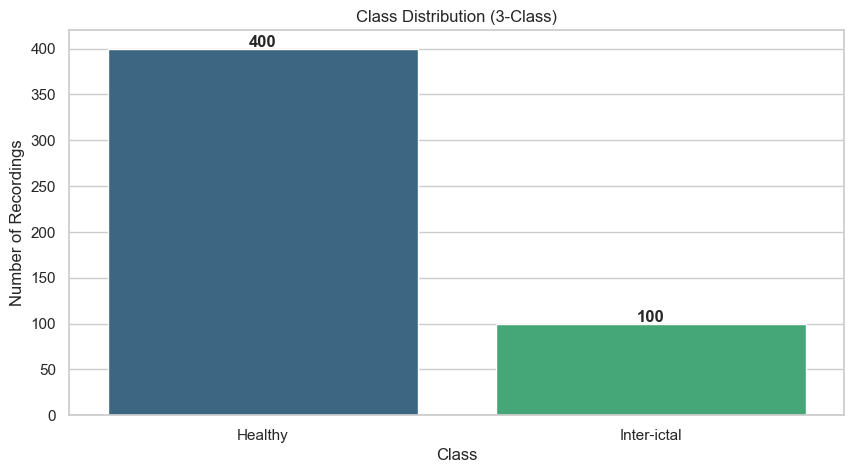

In [13]:
unique, counts = np.unique(y, return_counts=True)
class_names = {0: 'Healthy', 1: 'Inter-ictal', 2: 'Seizure'}
labels = [class_names[u] for u in unique]

plt.figure(figsize=(10, 5))
barplot = sns.barplot(x=labels, y=counts, palette='viridis')
plt.title("Class Distribution (3-Class)")
plt.xlabel("Class")
plt.ylabel("Number of Recordings")
for i, count in enumerate(counts):
    barplot.text(i, count + 2, str(count), ha='center', fontweight='bold')
plt.show()

## 3. Signal Visualization (Intra-Class Variability)
To better understand the signal differences, we plot **3 random samples** from each class. This highlights the variability even within the same category.

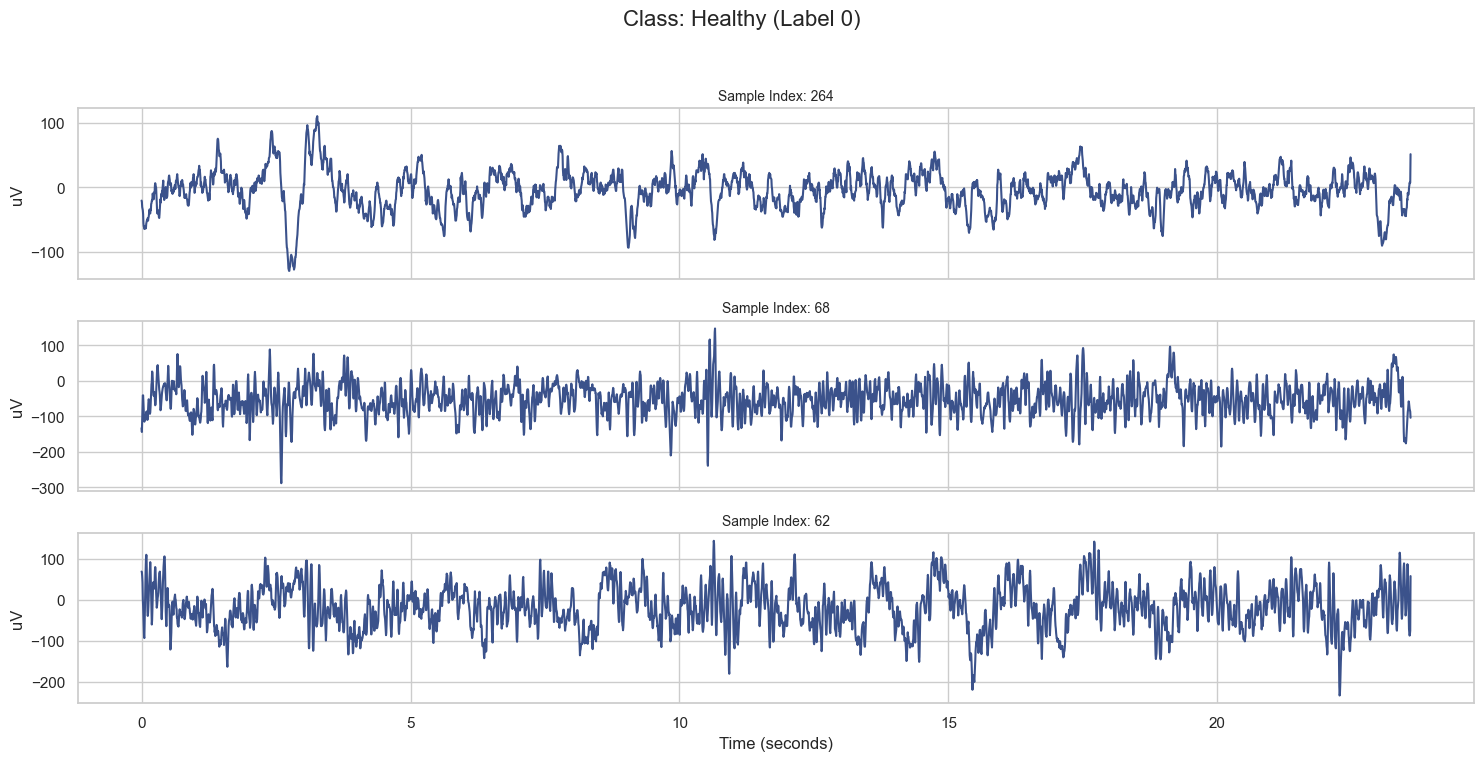

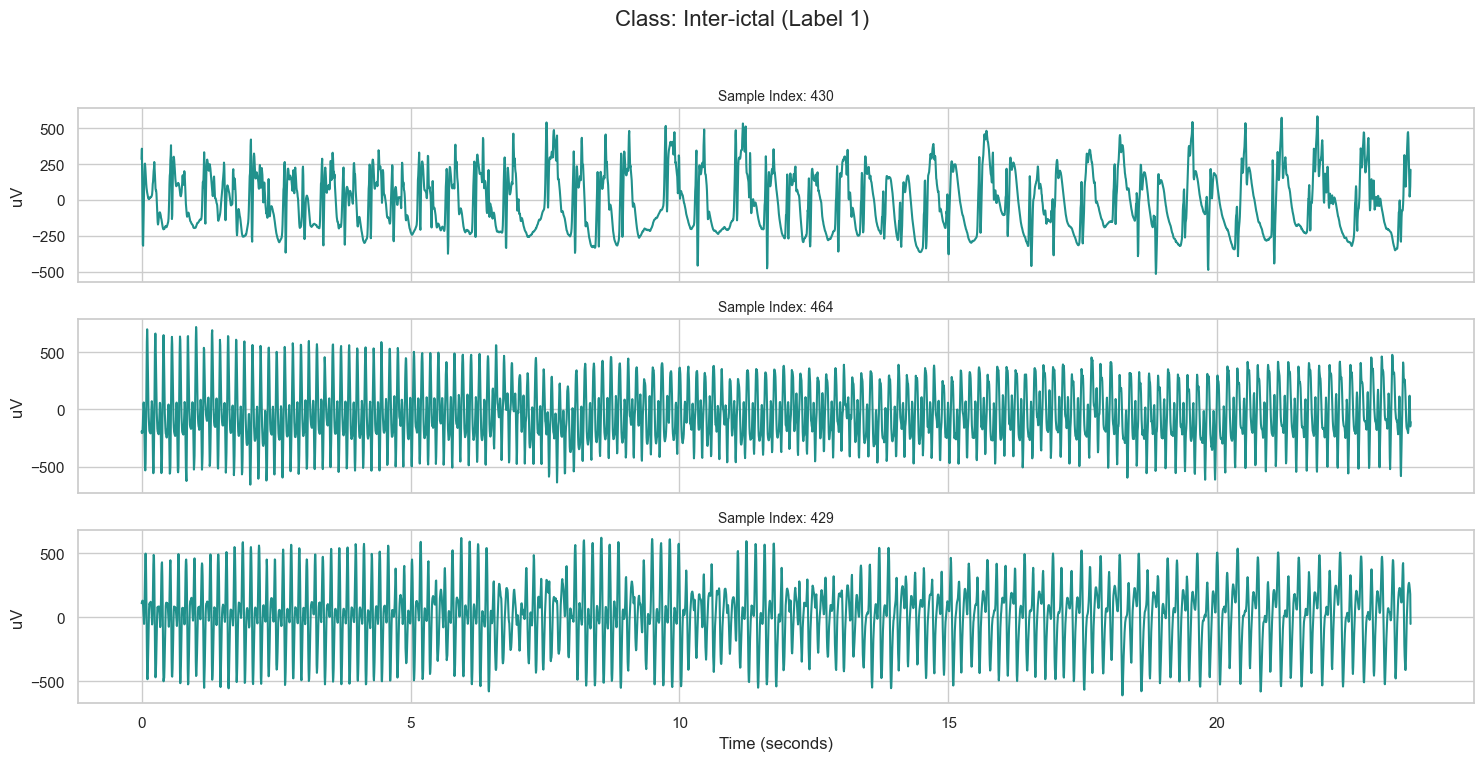

In [14]:
samples_to_plot = 3
fs = 173.61
time_axis = np.arange(X.shape[1]) / fs

for label in unique:
    indices = np.where(y == label)[0]
    # Select random samples
    selected_indices = np.random.choice(indices, samples_to_plot, replace=False)
    
    fig, axes = plt.subplots(samples_to_plot, 1, figsize=(15, 8), sharex=True)
    fig.suptitle(f"Class: {class_names[label]} (Label {label})", fontsize=16)
    
    for i, idx in enumerate(selected_indices):
        axes[i].plot(time_axis, X[idx], color=sns.color_palette("viridis", 3)[label])
        axes[i].set_ylabel("uV")
        axes[i].set_title(f"Sample Index: {idx}", fontsize=10)
        
    axes[-1].set_xlabel("Time (seconds)")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

## 4. Amplitude Statistics
We calculate basic amplitude statistics (Mean, Min, Max, Peak-to-Peak) to quantify the signal strength. Seizure signals typically exhibit much larger amplitudes.

In [15]:
stats = []
for label in unique:
    indices = np.where(y == label)[0]
    class_data = X[indices]
    
    mean_amp = np.mean(np.abs(class_data))
    max_amp = np.max(class_data)
    min_amp = np.min(class_data)
    std_amp = np.mean(np.std(class_data, axis=1))
    
    stats.append({
        'Class': class_names[label],
        'Mean Abs Amplitude': mean_amp,
        'Max Amplitude': max_amp,
        'Min Amplitude': min_amp,
        'Avg Std Dev': std_amp
    })

df_stats = pd.DataFrame(stats)
display(df_stats)

,Class,Mean Abs Amplitude,Max Amplitude,Min Amplitude,Avg Std Dev
0,Healthy,48.336870,2047.0,-1147.0,54.567189
1,Inter-ictal,244.462988,2047.0,-1885.0,306.572692


> **Observation:** Notice the significantly higher Standard Deviation and Amplitude range for **Ictal (Seizure)** signals compared to Healthy and Inter-ictal. This high variance is a key distinguishing feature.